# This is a notebook specified on drawing the unbinned fit on A/E spectrum from different filter Kernels

In [1]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [2]:
from pathlib import Path
runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
]

map_dir = Path(
    "/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
)
def map_path(config):
    map_dir ="/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
    return map_dir+"/map_calibration_"+config+".yaml"
data_cleaning_path = (
    "/mnt/atlas02/users/leoli/self_metadata/data_cleaning.yaml"
)
map_path('s100ns_mw5')

'/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs/map_calibration_s100ns_mw5.yaml'

In [29]:
run= "s100ns_mw5"

In [30]:
dfs_evt,lts_evt = {},{}
dfs_evt["r059"], lts_evt["r059"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)

In [31]:
dfs_phy_evt = dfs_evt['r059']['ch002']

In [32]:
argon_veto = np.asarray(dfs_phy_evt.is_lar_vetoed)
muon_veto = np.asarray(dfs_phy_evt.is_muon)
alpha_veto = np.asarray(dfs_phy_evt.A_max_o_E_High_Side_Cut & (dfs_phy_evt.Iasy<0))

In [33]:
dfs_1, lts_1 = {}, {}
dfs_1["r059"], lts_1["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(run),
    data_cleaning_path,
    "hit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)

In [34]:
dfs_phy = dfs_1['r059']['ch002']

In [35]:
E_1=np.asarray(dfs_phy.trapEmax_fix_cal)
A_max_mw_o_E_fix_Classifier = np.asarray(dfs_phy.A_max_mw_o_E_fix_Classifier)
is_valid_waveform_1 = np.asarray(dfs_phy.is_valid_waveform)

In [36]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/survival_db_from_dataprod.pkl", "rb") as f:
    survival_db = pickle.load(f)
ROI_mask = (E_1 > 1839) & (E_1 < 2239)
cut_value= survival_db[run]['cut_value_90']

In [48]:
# Check that all arrays correspond to the same events
assert (
    A_max_mw_o_E_fix_Classifier.shape
    == ROI_mask.shape
    == argon_veto.shape
    # == low_cut_1.shape
    # == low_cut_2.shape
), (
    f"Shape mismatch: "
    f"A_max_mw_o_E_Classifier_1={A_max_mw_o_E_fix_Classifier.shape}, "
    f"ROI_mask={ROI_mask.shape}, "
    # f"low_cut_1={low_cut_1.shape}, "
    # f"low_cut_2={low_cut_2.shape}"
)

# ROI selection plus finite classifier values
selection = (
    ROI_mask
    & np.isfinite(A_max_mw_o_E_fix_Classifier)
    # & np.isfinite(A_max_mw_o_E_Classifier_2)
    # & ~argon_veto
    & ~muon_veto
    & alpha_veto
)

# Selected classifier values
aoe_clean = A_max_mw_o_E_fix_Classifier[selection]

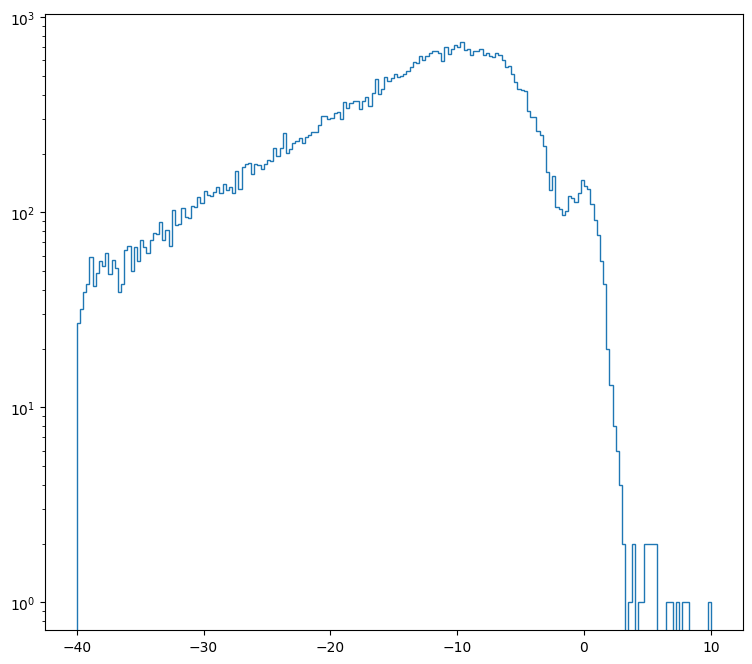

In [49]:
fig,ax = plt.subplots(figsize=(9, 8))
range=(-40,10)
ax.hist(aoe_clean,bins=200,range=range,histtype='step')
ax.set_yscale('log')


## GPT solution to the problem

In [50]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks


def locate_peak_and_valley(
    data,
    search_range=(-8.0, 2.0),
    peak_range=(-1.5, 1.5),
    bw_method=0.12,
    max_kde_events=50_000,
    random_seed=1,
):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    # Only use the relevant region for locating the structures.
    locator_data = data[
        (data >= search_range[0]) &
        (data <= search_range[1])
    ]

    # KDE evaluation can be expensive for millions of events.
    # The fit below still uses all events.
    if len(locator_data) > max_kde_events:
        rng = np.random.default_rng(random_seed)
        locator_data = rng.choice(
            locator_data,
            size=max_kde_events,
            replace=False,
        )

    grid = np.linspace(
        search_range[0],
        search_range[1],
        1500,
    )

    kde = gaussian_kde(locator_data, bw_method=bw_method)
    density = kde(grid)

    prominence = 0.01 * (density.max() - density.min())

    # --------------------------------------------------------
    # Peak: choose a significant local maximum near zero
    # --------------------------------------------------------
    peak_indices, _ = find_peaks(
        density,
        prominence=prominence,
    )

    valid_peaks = peak_indices[
        (grid[peak_indices] >= peak_range[0]) &
        (grid[peak_indices] <= peak_range[1])
    ]

    if len(valid_peaks) > 0:
        # From the peaks around zero, select the closest to zero.
        peak_index = valid_peaks[
            np.argmin(np.abs(grid[valid_peaks]))
        ]
    else:
        # Fallback: largest KDE value inside the expected peak range.
        peak_mask = (
            (grid >= peak_range[0]) &
            (grid <= peak_range[1])
        )

        peak_candidates = np.where(peak_mask)[0]
        peak_index = peak_candidates[
            np.argmax(density[peak_mask])
        ]

    peak_position = grid[peak_index]

    # --------------------------------------------------------
    # Valley: locate minima by finding peaks in -density
    # --------------------------------------------------------
    valley_indices, _ = find_peaks(
        -density,
        prominence=prominence,
    )

    valid_valleys = valley_indices[
        (grid[valley_indices] < peak_position - 0.25) &
        (grid[valley_indices] > peak_position - 6.0)
    ]

    if len(valid_valleys) > 0:
        # Select the nearest significant valley on the left.
        valley_index = valid_valleys[
            np.argmax(grid[valid_valleys])
        ]
    else:
        # Fallback: absolute minimum in the allowed left region.
        valley_mask = (
            (grid > peak_position - 6.0) &
            (grid < peak_position - 0.25)
        )

        valley_candidates = np.where(valley_mask)[0]
        valley_index = valley_candidates[
            np.argmin(density[valley_mask])
        ]

    valley_position = grid[valley_index]

    return {
        "peak": peak_position,
        "valley": valley_position,
        "grid": grid,
        "density": density,
    }

In [51]:
data = np.asarray(
    aoe_clean,
    dtype=float,
)

location = locate_peak_and_valley(data)

peak_initial = location["peak"]
valley_initial = location["valley"]

print(f"Initial peak:   {peak_initial:.3f}")
print(f"Initial valley: {valley_initial:.3f}")

Initial peak:   -0.008
Initial valley: -1.629


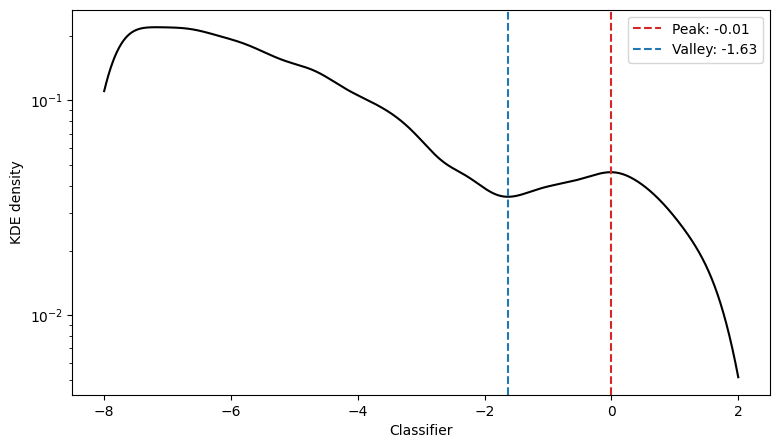

In [53]:
plt.figure(figsize=(9, 5))

plt.plot(
    location["grid"],
    location["density"],
    color="black",
)

plt.axvline(
    peak_initial,
    color="tab:red",
    linestyle="--",
    label=f"Peak: {peak_initial:.2f}",
)

plt.axvline(
    valley_initial,
    color="tab:blue",
    linestyle="--",
    label=f"Valley: {valley_initial:.2f}",
)

plt.xlabel("Classifier")
plt.ylabel("KDE density")
plt.yscale('log')
plt.legend()
plt.show()

In [56]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks, peak_prominences


def locate_peak_and_valley_kde(
    data,
    search_range=(-8.0, 2.0),
    peak_range=(-1.5, 1.5),
    valley_distance_range=(0.25, 6.0),
    bw_method=0.12,
    min_relative_prominence=0.01,
    prominence_window=6.0,
    grid_size=2000,
    histogram_bins=150,
    max_kde_events=50_000,
    random_seed=1,
    plot=True,
    title=None,
):
    """
    Locate a local peak near zero and the nearest significant valley
    to its left using a KDE.

    Parameters
    ----------
    data : array-like
        Original unbinned event values.

    search_range : tuple
        Full x range used for the KDE.

    peak_range : tuple
        Allowed region for the near-zero peak.

    valley_distance_range : tuple
        Minimum and maximum allowed distance of the valley to the
        left of the peak.

    bw_method : float
        KDE bandwidth factor. Smaller values resolve narrower
        structures but may produce more noise.

    min_relative_prominence : float
        Required prominence divided by the total KDE density range.
        For example, 0.01 corresponds to 1%.

    prominence_window : float or None
        Physical x width used to calculate local prominence.
        If None, global prominence is calculated.

    max_kde_events : int
        Maximum number of events used for the KDE locator.
        The later unbinned fit can still use all events.

    Returns
    -------
    result : dict
        Dictionary containing peak and valley positions,
        prominences, KDE arrays, and base positions.
    """

    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    search_mask = (
        (data >= search_range[0]) &
        (data <= search_range[1])
    )

    search_data = data[search_mask]

    if len(search_data) < 10:
        raise ValueError(
            "Not enough events inside the selected search range."
        )

    # Use a subset only for the KDE calculation if necessary.
    # This does not modify the original data array.
    if len(search_data) > max_kde_events:
        rng = np.random.default_rng(random_seed)

        kde_data = rng.choice(
            search_data,
            size=max_kde_events,
            replace=False,
        )
    else:
        kde_data = search_data

    # ------------------------------------------------------------
    # Calculate KDE
    # ------------------------------------------------------------
    grid = np.linspace(
        search_range[0],
        search_range[1],
        grid_size,
    )

    kde = gaussian_kde(
        kde_data,
        bw_method=bw_method,
    )

    density = kde(grid)

    density_range = density.max() - density.min()

    if density_range <= 0:
        raise ValueError("The KDE density has no variation.")

    # ------------------------------------------------------------
    # Convert physical prominence window to grid points
    # ------------------------------------------------------------
    dx = grid[1] - grid[0]

    if prominence_window is None:
        wlen = None
    else:
        wlen = int(np.round(prominence_window / dx))

        # peak_prominences requires a window larger than one.
        wlen = max(wlen, 3)

        # Use an odd window length.
        if wlen % 2 == 0:
            wlen += 1

        # Avoid a window longer than the entire KDE grid.
        if wlen >= len(grid):
            wlen = len(grid) - 1

            if wlen % 2 == 0:
                wlen -= 1

    # ============================================================
    # Find peaks
    # ============================================================
    all_peak_indices, _ = find_peaks(density)

    if len(all_peak_indices) == 0:
        raise RuntimeError(
            "No local peaks were found. Try reducing bw_method."
        )

    (
        all_peak_prominences,
        all_peak_left_bases,
        all_peak_right_bases,
    ) = peak_prominences(
        density,
        all_peak_indices,
        wlen=wlen,
    )

    all_peak_relative_prominences = (
        all_peak_prominences / density_range
    )

    # Restrict the possible peaks to the region around zero.
    allowed_peak_mask = (
        (grid[all_peak_indices] >= peak_range[0]) &
        (grid[all_peak_indices] <= peak_range[1])
    )

    peak_candidates = np.where(allowed_peak_mask)[0]

    if len(peak_candidates) == 0:
        raise RuntimeError(
            "No KDE peak was found inside peak_range. "
            "Try widening peak_range or reducing bw_method."
        )

    # First try peaks that satisfy the requested prominence.
    significant_peak_candidates = peak_candidates[
        all_peak_relative_prominences[peak_candidates]
        >= min_relative_prominence
    ]

    if len(significant_peak_candidates) > 0:
        peak_candidates = significant_peak_candidates
    else:
        print(
            "Warning: no peak satisfies the minimum relative "
            "prominence. Using the most prominent peak in peak_range."
        )

    # Choose the most prominent peak inside peak_range.
    selected_peak_number = peak_candidates[
        np.argmax(all_peak_prominences[peak_candidates])
    ]

    peak_index = all_peak_indices[selected_peak_number]

    peak_position = grid[peak_index]
    peak_height = density[peak_index]

    peak_prominence = all_peak_prominences[
        selected_peak_number
    ]

    peak_relative_prominence = (
        peak_prominence / density_range
    )

    peak_left_base_index = all_peak_left_bases[
        selected_peak_number
    ]

    peak_right_base_index = all_peak_right_bases[
        selected_peak_number
    ]

    # The higher of the two base densities defines the contour.
    peak_base_height = (
        peak_height - peak_prominence
    )

    # ============================================================
    # Find valleys as peaks in the inverted KDE
    # ============================================================
    inverted_density = -density

    all_valley_indices, _ = find_peaks(
        inverted_density
    )

    if len(all_valley_indices) == 0:
        raise RuntimeError(
            "No local valleys were found. Try reducing bw_method."
        )

    (
        all_valley_prominences,
        all_valley_left_bases,
        all_valley_right_bases,
    ) = peak_prominences(
        inverted_density,
        all_valley_indices,
        wlen=wlen,
    )

    all_valley_relative_prominences = (
        all_valley_prominences / density_range
    )

    minimum_distance = valley_distance_range[0]
    maximum_distance = valley_distance_range[1]

    valley_distances = (
        peak_position - grid[all_valley_indices]
    )

    allowed_valley_mask = (
        (valley_distances >= minimum_distance) &
        (valley_distances <= maximum_distance)
    )

    valley_candidates = np.where(
        allowed_valley_mask
    )[0]

    if len(valley_candidates) == 0:
        raise RuntimeError(
            "No valley was found in the allowed region left of "
            "the peak. Try changing valley_distance_range."
        )

    significant_valley_candidates = valley_candidates[
        all_valley_relative_prominences[valley_candidates]
        >= min_relative_prominence
    ]

    if len(significant_valley_candidates) > 0:
        valley_candidates = significant_valley_candidates
    else:
        print(
            "Warning: no valley satisfies the minimum relative "
            "prominence. Using the most prominent allowed valley."
        )

    # Select the nearest significant valley to the left.
    selected_valley_number = valley_candidates[
        np.argmin(valley_distances[valley_candidates])
    ]

    valley_index = all_valley_indices[
        selected_valley_number
    ]

    valley_position = grid[valley_index]
    valley_height = density[valley_index]

    valley_prominence = all_valley_prominences[
        selected_valley_number
    ]

    valley_relative_prominence = (
        valley_prominence / density_range
    )

    valley_left_base_index = all_valley_left_bases[
        selected_valley_number
    ]

    valley_right_base_index = all_valley_right_bases[
        selected_valley_number
    ]

    # For a valley, prominence extends upward from its minimum.
    valley_base_height = (
        valley_height + valley_prominence
    )
    peak_height = density[peak_index]
    valley_height = density[valley_index]

    peak_valley_difference = (
        peak_height - valley_height
    )

    relative_prominence = (
        peak_height - valley_height
    ) / peak_height

    # print(f"Peak position:       {peak_position:.4f}")
    # print(f"Valley position:     {valley_position:.4f}")
    # print(f"Peak height:         {peak_height:.6f}")
    # print(f"Valley height:       {valley_height:.6f}")
    # print(f"Peak-valley depth:   {peak_valley_difference:.6f}")
    # print(f"Relative prominence: {relative_prominence:.2%}")
    # ------------------------------------------------------------
    # Collect results
    # ------------------------------------------------------------
    result = {
        "peak_position": peak_position,
        "peak_height": peak_height,
        "peak_prominence": peak_prominence,
        "peak_relative_prominence": peak_relative_prominence,
        "peak_left_base": grid[peak_left_base_index],
        "peak_right_base": grid[peak_right_base_index],

        "valley_position": valley_position,
        "valley_height": valley_height,
        "valley_prominence": valley_prominence,
        "valley_relative_prominence": valley_relative_prominence,
        "valley_left_base": grid[valley_left_base_index],
        "valley_right_base": grid[valley_right_base_index],

        "relative_prominence": relative_prominence,
        
        "grid": grid,
        "density": density,

        "all_peak_positions": grid[all_peak_indices],
        "all_peak_prominences": all_peak_prominences,

        "all_valley_positions": grid[all_valley_indices],
        "all_valley_prominences": all_valley_prominences,

        "kde_bandwidth_factor": kde.factor,
        "number_of_kde_events": len(kde_data),
    }

    # ============================================================
    # Visualization
    # ============================================================
    if plot:
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(10, 9),
            sharex=True,
            gridspec_kw={
                "height_ratios": [1.0, 1.3],
                "hspace": 0.05,
            },
        )

        ax_hist, ax_kde = axes

        # --------------------------------------------------------
        # Upper panel: ordinary histogram
        # --------------------------------------------------------
        ax_hist.hist(
            search_data,
            bins=histogram_bins,
            range=search_range,
            histtype="step",
            color="black",
            linewidth=1.2,
        )

        ax_hist.axvline(
            peak_position,
            color="tab:red",
            linestyle="--",
            linewidth=1.5,
        )

        ax_hist.axvline(
            valley_position,
            color="tab:blue",
            linestyle="--",
            linewidth=1.5,
        )

        ax_hist.set_ylabel("Events per bin")
        ax_hist.set_yscale("log")

        if title is not None:
            ax_hist.set_title(title)

        # --------------------------------------------------------
        # Lower panel: KDE
        # --------------------------------------------------------
        ax_kde.plot(
            grid,
            density,
            color="black",
            linewidth=1.8,
            label="KDE",
        )

        # Show all detected peaks and valleys faintly.
        ax_kde.scatter(
            grid[all_peak_indices],
            density[all_peak_indices],
            marker="^",
            s=25,
            color="tab:red",
            alpha=0.25,
            label="All detected peaks",
        )

        ax_kde.scatter(
            grid[all_valley_indices],
            density[all_valley_indices],
            marker="v",
            s=25,
            color="tab:blue",
            alpha=0.25,
            label="All detected valleys",
        )

        # --------------------------------------------------------
        # Selected peak
        # --------------------------------------------------------
        ax_kde.scatter(
            peak_position,
            peak_height,
            marker="^",
            s=100,
            color="tab:red",
            zorder=5,
        )

        # Vertical peak prominence.
        ax_kde.vlines(
            peak_position,
            peak_base_height,
            peak_height,
            color="tab:red",
            linewidth=3,
            label="Peak prominence",
        )

        # Peak prominence contour.
        ax_kde.hlines(
            peak_base_height,
            grid[peak_left_base_index],
            grid[peak_right_base_index],
            color="tab:red",
            linestyle=":",
            linewidth=1.5,
        )

        # Peak base points.
        ax_kde.scatter(
            [
                grid[peak_left_base_index],
                grid[peak_right_base_index],
            ],
            [
                density[peak_left_base_index],
                density[peak_right_base_index],
            ],
            color="tab:red",
            marker="o",
            s=35,
            zorder=5,
        )

        # --------------------------------------------------------
        # Selected valley
        # --------------------------------------------------------
        ax_kde.scatter(
            valley_position,
            valley_height,
            marker="v",
            s=100,
            color="tab:blue",
            zorder=5,
        )

        # Vertical valley prominence.
        ax_kde.vlines(
            valley_position,
            valley_height,
            valley_base_height,
            color="tab:blue",
            linewidth=3,
            label="Valley prominence",
        )

        # Valley prominence contour.
        ax_kde.hlines(
            valley_base_height,
            grid[valley_left_base_index],
            grid[valley_right_base_index],
            color="tab:blue",
            linestyle=":",
            linewidth=1.5,
        )

        # Valley base points.
        ax_kde.scatter(
            [
                grid[valley_left_base_index],
                grid[valley_right_base_index],
            ],
            [
                density[valley_left_base_index],
                density[valley_right_base_index],
            ],
            color="tab:blue",
            marker="o",
            s=35,
            zorder=5,
        )

        # Position lines.
        ax_kde.axvline(
            peak_position,
            color="tab:red",
            linestyle="--",
            alpha=0.6,
        )

        ax_kde.axvline(
            valley_position,
            color="tab:blue",
            linestyle="--",
            alpha=0.6,
        )

        # Labels next to selected features.
        ax_kde.annotate(
            (
                f"Peak\n"
                f"x = {peak_position:.3f}\n"
                f"prom. = {peak_prominence:.4g}\n"
                f"relative = {peak_relative_prominence:.2%}"
            ),
            xy=(peak_position, peak_height),
            xytext=(12, 18),
            textcoords="offset points",
            color="tab:red",
            fontsize=10,
        )

        ax_kde.annotate(
            (
                f"Valley\n"
                f"x = {valley_position:.3f}\n"
                f"prom. = {valley_prominence:.4g}\n"
                f"relative = {valley_relative_prominence:.2%}"
            ),
            xy=(valley_position, valley_height),
            xytext=(-105, -65),
            textcoords="offset points",
            color="tab:blue",
            fontsize=10,
        )

        ax_kde.set_xlabel("Classifier")
        ax_kde.set_ylabel("KDE density")
        ax_kde.legend(
            loc="best",
            fontsize=9,
        )
        comparison_x = 0.5 * (
            peak_position + valley_position
        )   

        # Vertical line showing H_peak - H_valley
        ax_kde.vlines(
            comparison_x,
            valley_height,
            peak_height,
            color="tab:purple",
            linewidth=3,
            label="Peak-valley difference",
        )

        # Small horizontal caps
        cap_width = 0.08 * (
            search_range[1] - search_range[0]
        )

        ax_kde.hlines(
            [peak_height, valley_height],
            comparison_x - cap_width / 2,
            comparison_x + cap_width / 2,
            color="tab:purple",
            linewidth=1.5,
        )

        ax_kde.annotate(
            (
                rf"$\frac{{H_p-H_v}}{{H_p}}$"
                f" = {relative_prominence:.2%}"
            ),
            xy=(
                comparison_x,
                0.5 * (peak_height + valley_height),
            ),
            xytext=(10, 0),
            textcoords="offset points",
            color="tab:purple",
            va="center",
            fontsize=11,
        )
        plt.show()

        result["figure"] = fig
        result["axes"] = axes

    return result

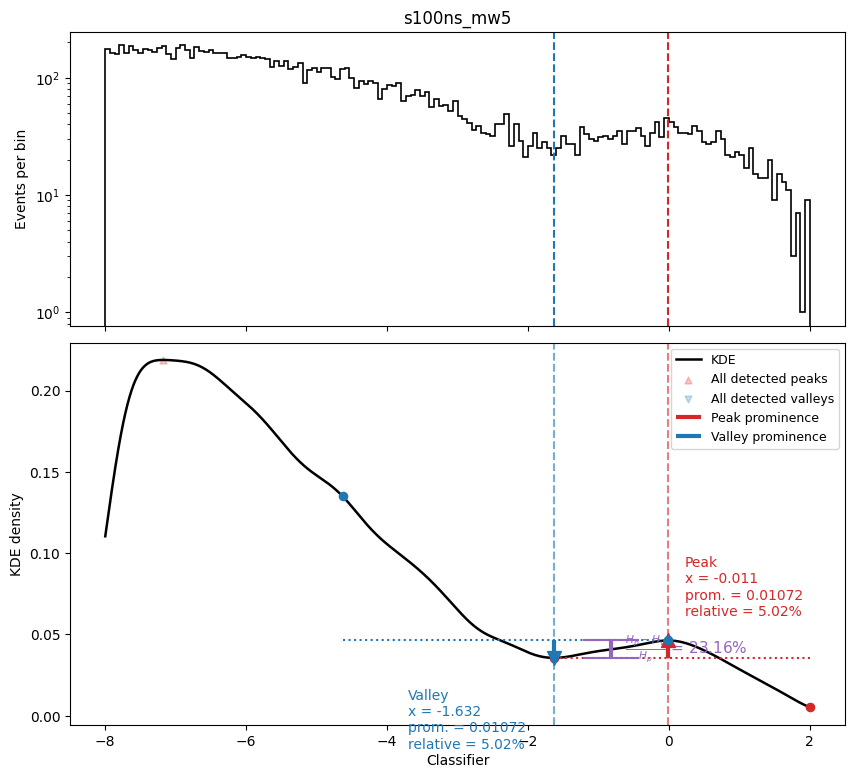

In [57]:
data = np.asarray(
    aoe_clean,
    dtype=float,
)

result = locate_peak_and_valley_kde(
    data,
    search_range=(-8, 2),
    peak_range=(-1.5, 1.5),
    valley_distance_range=(0.25, 6.0),
    bw_method=0.12,
    min_relative_prominence=0.01,
    prominence_window=6.0,
    title=run,
)

In [58]:
def measure_kde_quantities(
    data,
    search_range=(-8.0, 2.0),
    peak_range=(-1.5, 1.5),
    bw_method=0.12,
):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    result = locate_peak_and_valley(
        data,
        search_range=search_range,
        peak_range=peak_range,
        bw_method=bw_method,

        # Use all supplied events, avoiding additional random
        # subsampling inside locate_peak_and_valley().
        max_kde_events=len(data),
    )

    peak_position = result["peak"]
    valley_position = result["valley"]

    peak_height = np.interp(
        peak_position,
        result["grid"],
        result["density"],
    )

    valley_height = np.interp(
        valley_position,
        result["grid"],
        result["density"],
    )

    relative_prominence = (
        peak_height - valley_height
    ) / peak_height

    return {
        "peak": peak_position,
        "valley": valley_position,
        "peak_height": peak_height,
        "valley_height": valley_height,
        "relative_prominence": relative_prominence,
        "grid": result["grid"],
        "density": result["density"],
    }

In [59]:
def jackknife_kde_uncertainty(
    data,
    n_groups=20,
    search_range=(-8.0, 2.0),
    peak_range=(-1.5, 1.5),
    bw_method=0.12,
    plot=True,
):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    data = data[
        (data >= search_range[0]) &
        (data <= search_range[1])
    ]

    if len(data) < n_groups:
        raise ValueError(
            "n_groups cannot exceed the number of events."
        )

    # Central values calculated using the full dataset.
    central = measure_kde_quantities(
        data,
        search_range=search_range,
        peak_range=peak_range,
        bw_method=bw_method,
    )

    # Contiguous blocks are useful when event ordering corresponds
    # to acquisition time.
    index_groups = np.array_split(
        np.arange(len(data)),
        n_groups,
    )

    jackknife_values = []

    for group_index, excluded_indices in enumerate(index_groups):
        keep = np.ones(len(data), dtype=bool)
        keep[excluded_indices] = False

        reduced_data = data[keep]

        try:
            result = measure_kde_quantities(
                reduced_data,
                search_range=search_range,
                peak_range=peak_range,
                bw_method=bw_method,
            )

            jackknife_values.append([
                result["peak"],
                result["valley"],
                result["peak_height"],
                result["valley_height"],
                result["relative_prominence"],
            ])

        except (ValueError, RuntimeError):
            print(
                f"Jackknife group {group_index} failed."
            )

    jackknife_values = np.asarray(
        jackknife_values
    )

    number_successful = len(jackknife_values)

    if number_successful < 2:
        raise RuntimeError(
            "Too few successful jackknife calculations."
        )

    jackknife_mean = np.mean(
        jackknife_values,
        axis=0,
    )

    jackknife_errors = np.sqrt(
        (number_successful - 1) / number_successful
        * np.sum(
            (
                jackknife_values
                - jackknife_mean
            )**2,
            axis=0,
        )
    )

    result = {
        "peak": central["peak"],
        "peak_error": jackknife_errors[0],

        "valley": central["valley"],
        "valley_error": jackknife_errors[1],

        "peak_height": central["peak_height"],
        "peak_height_error": jackknife_errors[2],

        "valley_height": central["valley_height"],
        "valley_height_error": jackknife_errors[3],

        "relative_prominence":
            central["relative_prominence"],

        "relative_prominence_error":
            jackknife_errors[4],

        "jackknife_values": jackknife_values,
        "number_successful": number_successful,

        "grid": central["grid"],
        "density": central["density"],
    }

    if plot:
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(9, 8),
            gridspec_kw={
                "height_ratios": [1.3, 1],
                "hspace": 0.3,
            },
        )

        ax_kde, ax_jackknife = axes

        # KDE result
        ax_kde.plot(
            central["grid"],
            central["density"],
            color="black",
            label="Full-data KDE",
        )

        ax_kde.scatter(
            central["peak"],
            central["peak_height"],
            color="tab:red",
            marker="^",
            s=90,
            label=(
                f"Peak: {central['peak']:.3f} "
                f"± {jackknife_errors[0]:.3f}"
            ),
        )

        ax_kde.scatter(
            central["valley"],
            central["valley_height"],
            color="tab:blue",
            marker="v",
            s=90,
            label=(
                f"Valley: {central['valley']:.3f} "
                f"± {jackknife_errors[1]:.3f}"
            ),
        )

        ax_kde.vlines(
            central["peak"],
            central["valley_height"],
            central["peak_height"],
            color="tab:purple",
            linewidth=3,
        )

        ax_kde.set_xlabel("Classifier")
        ax_kde.set_ylabel("KDE density")
        ax_kde.legend()

        # Distribution of leave-one-group-out results
        ax_jackknife.hist(
            jackknife_values[:, 4],
            bins=min(15, number_successful),
            histtype="stepfilled",
            color="tab:purple",
            alpha=0.35,
        )

        ax_jackknife.axvline(
            central["relative_prominence"],
            color="black",
            label=(
                rf"$P_{{rel}} = "
                rf"{central['relative_prominence']:.4f}"
                rf"\pm{jackknife_errors[4]:.4f}$"
            ),
        )

        ax_jackknife.set_xlabel(
            r"$(H_{\rm peak}-H_{\rm valley})"
            r"/H_{\rm peak}$"
        )

        ax_jackknife.set_ylabel(
            "Leave-one-group-out results"
        )

        ax_jackknife.legend()

        plt.show()

        result["figure"] = fig
        result["axes"] = axes

    return result

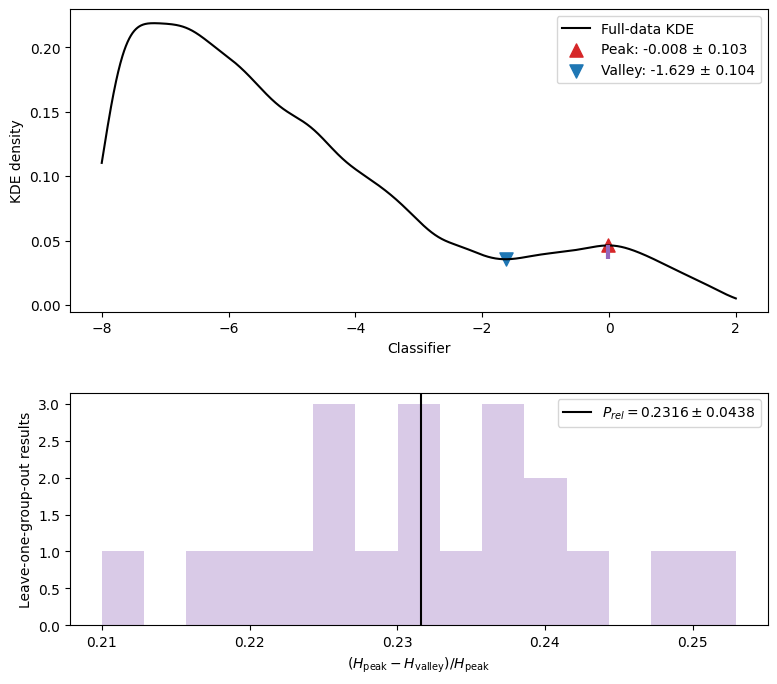

Relative prominence = 0.2316 ± 0.0438


In [60]:
result = jackknife_kde_uncertainty(
    data,
    n_groups=20,
    search_range=(-8, 2),
    peak_range=(-1.5, 1.5),
    bw_method=0.12,
    plot=True,
)

print(
    f"Relative prominence = "
    f"{result['relative_prominence']:.4f} "
    f"± {result['relative_prominence_error']:.4f}"
)